In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [2]:
df = pd.read_csv(" Polynomial_Regression_Dataset.csv")

In [3]:
df.head()

,Feature_1,Feature_2,Target
0,1,10,12
1,2,9,24
2,3,8,38
3,4,7,54
4,5,6,72


In [4]:
X = df.drop("Target", axis = 1)
y = df["Target"]

In [5]:
X.head()

,Feature_1,Feature_2
0,1,10
1,2,9
2,3,8
3,4,7
4,5,6


In [6]:
y.head()

,Target
0,12
1,24
2,38
3,54
4,72


In [7]:
poly_features = PolynomialFeatures(degree=5)

In [8]:
X_poly = poly_features.fit_transform(X)

In [9]:
X_poly[0]

array([1.e+00, 1.e+00, 1.e+01, 1.e+00, 1.e+01, 1.e+02, 1.e+00, 1.e+01,
       1.e+02, 1.e+03, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+00,
       1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05])

In [10]:
poly_reg_model = LinearRegression()
poly_reg_model.fit(X_poly, y)

LinearRegression()

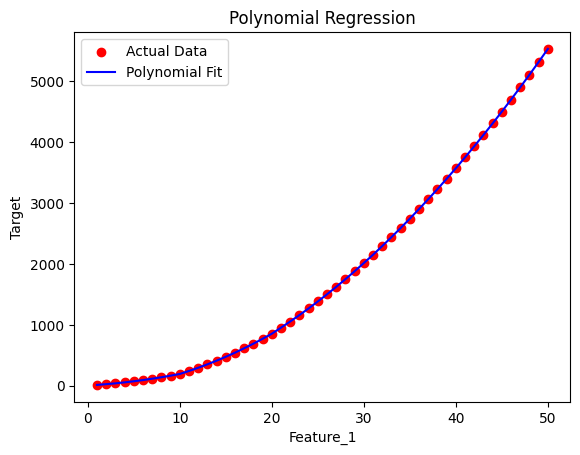

In [11]:
X_sorted = X.sort_values(by="Feature_1")
x_poly_sorted = poly_features.fit_transform(X_sorted)
y_pred = poly_reg_model.predict(x_poly_sorted)
plt.scatter(X["Feature_1"], y, color="red", label = "Actual Data")
plt.plot(X_sorted["Feature_1"], y_pred, color="blue", label = "Polynomial Fit")
plt.title("Polynomial Regression")
plt.xlabel("Feature_1")
plt.ylabel("Target")
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
y_pred_orignal = poly_reg_model.predict(X_poly)
r2 = r2_score(y, y_pred_orignal)
mae = mean_absolute_error(y, y_pred_orignal)
mse = mean_squared_error(y, y_pred_orignal)
rmse = np.sqrt(mse)
print(f"R2 Score: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

R2 Score: 1.0000
Mean Absolute Error: 0.2926
Mean Squared Error: 0.1509
Root Mean Squared Error: 0.3884
